Solution Computational Foundation of Electrodynamics 4rd ed - Reitz, John .R

CHAPTER 2.Electrostatics 

In [2]:
import numpy as np
import scipy as sp
import sympy as smp
import matplotlib.pyplot as plt
from sympy.vector import CoordSys3D
plt.rcParams['text.usetex'] = True
#import EMG_T as *

In [3]:
PI = sp.constants.pi
MU_0 = sp.constants.mu_0
EPLSILON_0 = sp.constants.epsilon_0
E_CHARGE = sp.constants.elementary_charge
ELECTRON_MASS = sp.constants.electron_mass
GRAVITY = sp.constants.g
K_COLUMN = 1/(4*PI*EPLSILON_0)

<div style="display: flex; justify-content: center; align-items: center; gap: 10px;">
  <img src="Column's Law.png" width="600">
  <img src="Electric Field.png" width="600">
</div>

$$ \vec{F}(\vec{r}_{ij}) = \frac{1}{4 \pi \epsilon_0} \sum_{i\neq j}^{N} \frac{q_i q_j}{{\Vert \vec{r}_i - \vec{r}_j\Vert}^2} \hat{r}_{ij} \quad \quad  \hat{r}_{ij} = \frac{\vec{r}_i - \vec{r}_j}{\Vert \vec{r}_i - \vec{r}_j\Vert} $$
$$ \vec{E}_j(\vec{r}_{ij}) = \sum_{i\neq j}^{N} \frac{q_j}{4 \pi \epsilon_0} (\frac{x_i-x_j}{{\vec{r}_{ij}}^3} \hat{x} + \frac{y_i-y_j}{{\vec{r}_{ij}}^3} \hat{y} + \frac{z_i-z_j}{{\vec{r}_{ij}}^3} \hat{z})$$
$$ {r_{ij}} = \Vert \vec{r}_i - \vec{r}_j\Vert = [(x_i-x_j)^2+(y_i-y_j)^2+(z_i-z_j)^2]^{1/2} $$
$$ {r_{ij}}^3 = \Vert \vec{r}_i - \vec{r}_j\Vert^3 = [(x_i-x_j)^2+(y_i-y_j)^2+(z_i-z_j)^2]^{3/2} $$

In [4]:
def r_ij(r_i: np.ndarray, r_j: np.ndarray): return np.linalg.norm(r_i-r_j)

## Problems

2.1

In [5]:
# q = float(input('Enter q: ')) 
q = 2
# m = float(input('Enter mass: '))
m = ELECTRON_MASS
# l = float(input('Enter length: '))
l = 2

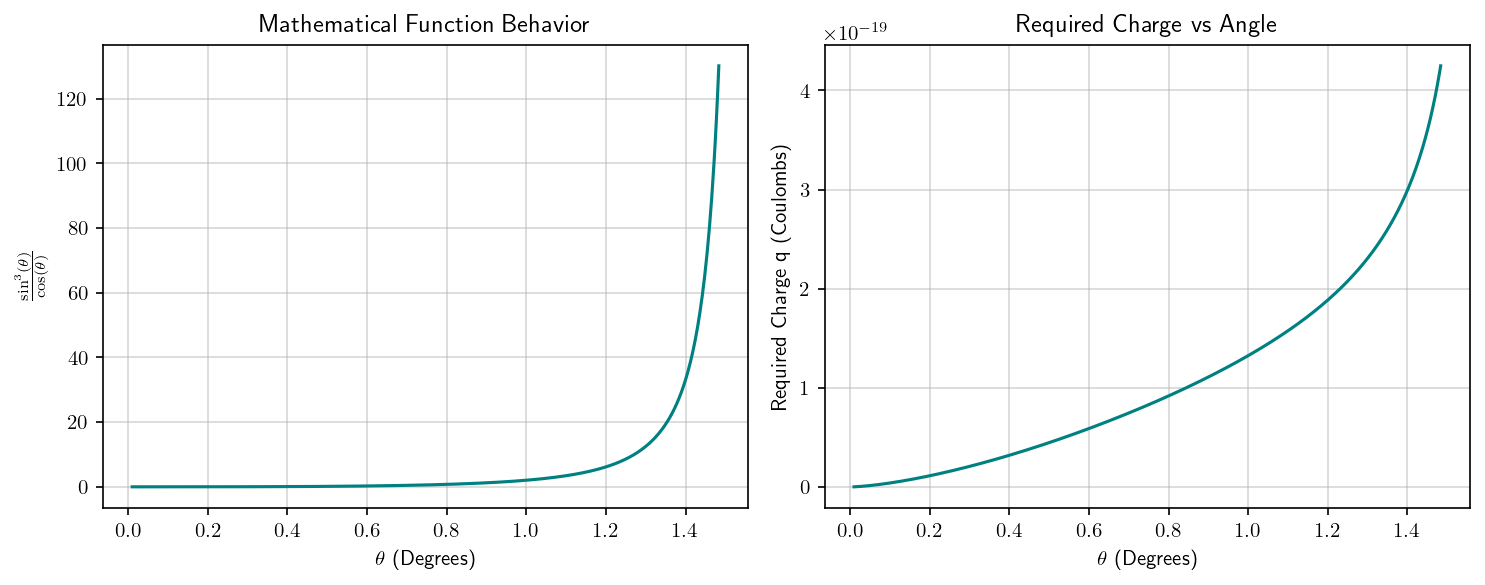

In [6]:
theta_range = np.linspace(0.01, np.radians(85), 500) 
alpha = 1/(16*np.pi*EPLSILON_0*m*GRAVITY*l**2)
q_theta = np.sqrt(np.sin(theta_range)**3/(alpha*np.cos(theta_range)))
theta_eq = pow((q_theta**2)*alpha,1/3)

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,4),dpi=150)
for ax in [ax1,ax2]: ax.grid(alpha=0.5)
ax1.plot(theta_range,np.sin(theta_range)**3/np.cos(theta_range)**2,color='teal')
ax1.set_xlabel(r'$\theta$ (Degrees)')
ax1.set_ylabel(r'$\frac{\sin^3(\theta)}{\cos(\theta)}$')
ax1.set_title('Mathematical Function Behavior')
ax2.plot(theta_range,q_theta,color='teal')
ax2.set_xlabel(r'$\theta$ (Degrees)')
ax2.set_ylabel('Required Charge q (Coulombs)')
ax2.set_title('Required Charge vs Angle')

plt.tight_layout()

2.4

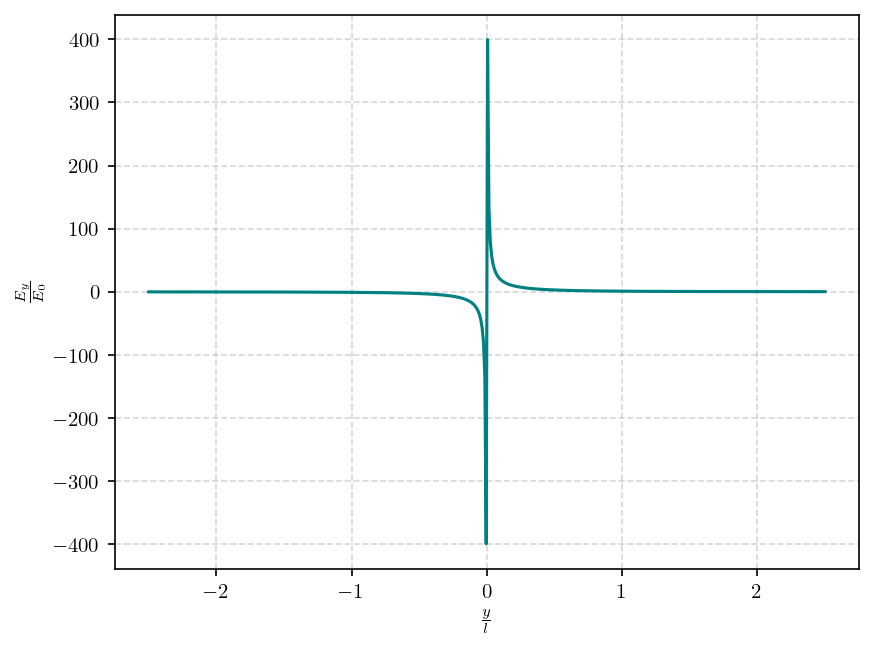

In [17]:
Lambda = np.linspace(-5,5,500)
y = np.linspace(-5,5,500)
Q = Lambda*l
Ey = (1/(4*np.pi*EPLSILON_0))*((Lambda*l)/y)*(1/np.sqrt(y**2+(l/2)**2))
E0 = Q/(4*np.pi*EPLSILON_0*l**2)

plt.figure(dpi=150)
plt.plot(y/l,Ey/E0,color='teal')
plt.ylabel(r'$\frac{E_y}{E_0}$')
plt.xlabel(r'$\frac{y}{l}$')
plt.grid(alpha=0.5,linestyle='--')

2.5

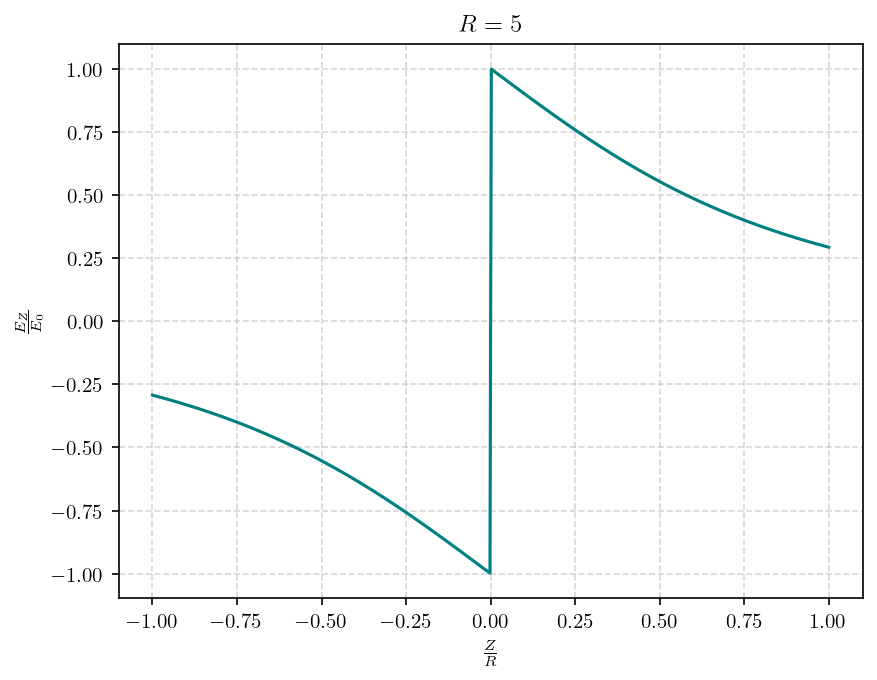

In [21]:
Sigma = np.linspace(-5,5,500)
z = np.linspace(-5,5,500)
Q = Sigma*l ; R = 5
Ez = (Sigma/(2*EPLSILON_0))*((z/abs(z))-(z/np.sqrt(R**2+z**2)))
E0 = Sigma/(2*EPLSILON_0)

plt.figure(dpi=150)
plt.plot(z/R,Ez/E0,color='teal')
plt.ylabel(r'$\frac{E_Z}{E_0}$')
plt.xlabel(r'$\frac{Z}{R}$')
plt.title(r'$R=5$')
plt.grid(alpha=0.5,linestyle='--')

2.7

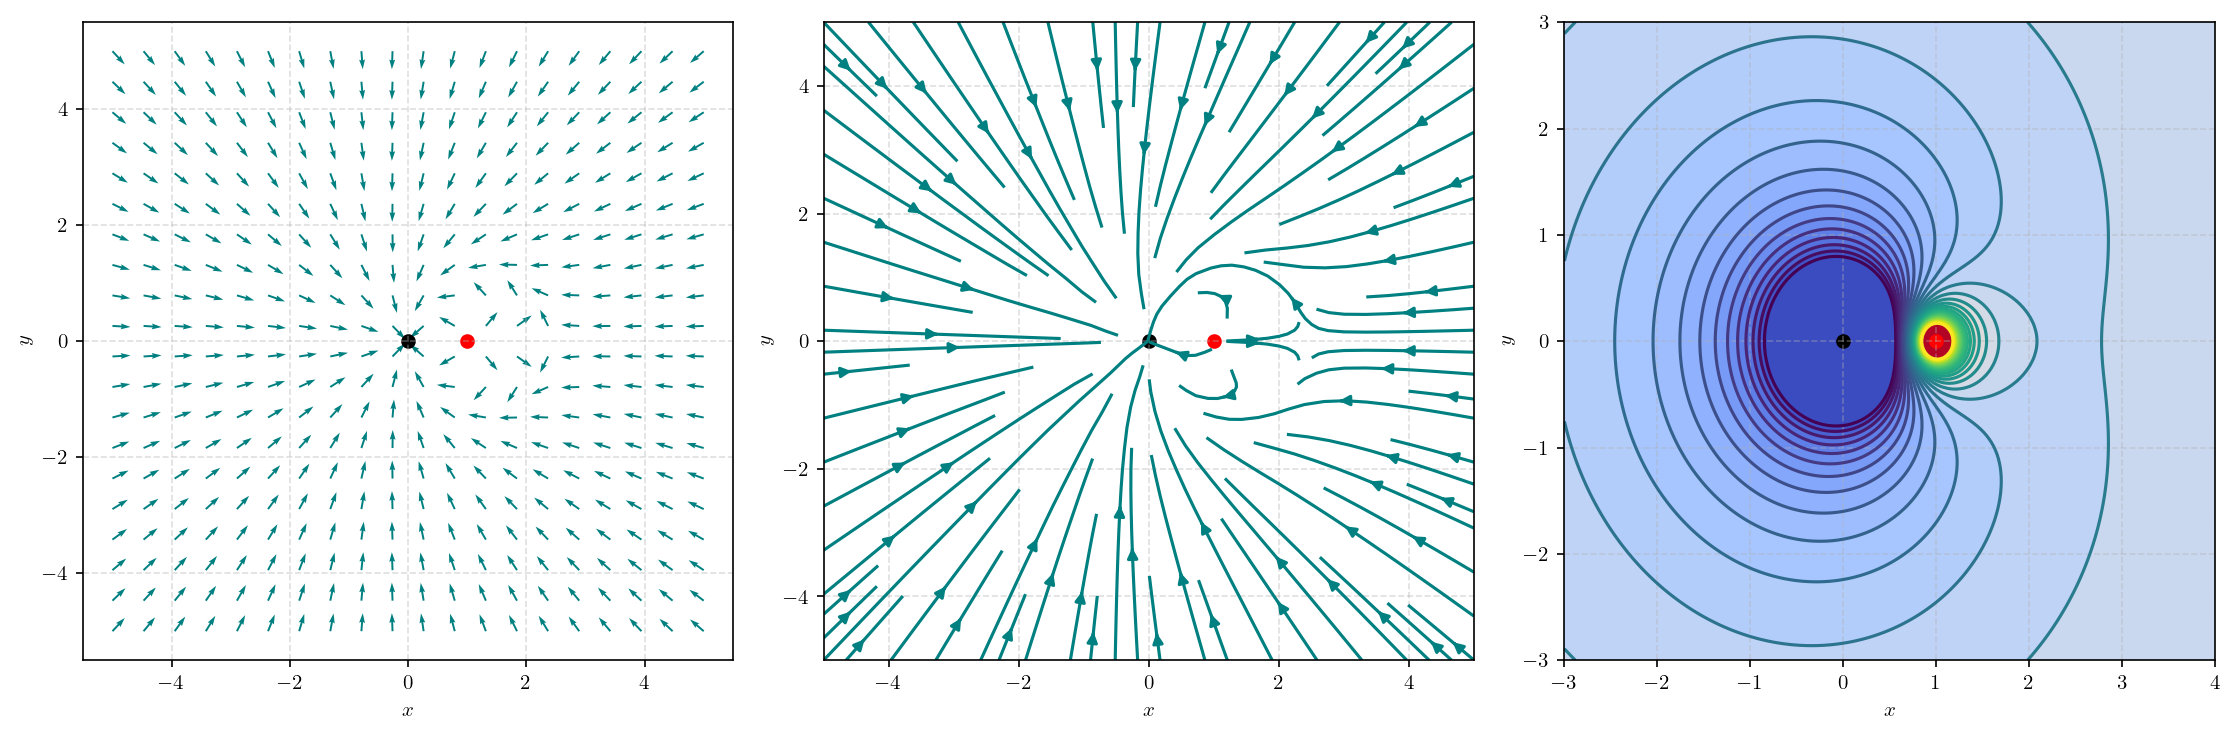

In [65]:
q1 = -1.0 ; q2 = 1/3 ; a = 1
x1, y1 = 0, 0 ; x2, y2 = a, 0
dif, ax = plt.subplots(1,3,figsize=(15,5),dpi=150)
x = np.linspace(-5,5,20)
y = np.linspace(-5,5,20)

X, Y = np.meshgrid(x,y)

R_1 = ((X - x1)**2 + (Y - y1)**2)**1.5 + 1e-10
R_2 = ((X - x2)**2 + (Y - y2)**2)**1.5 + 1e-10

VX1 = q1 * (X - x1) / R_1
VY1 = q1 * (Y - y1) / R_1

VX2 = q2 * (X - x2) / R_2
VY2 = q2 * (Y - y2) / R_2

VX = VX1 + VX2 
VY = VY1 + VY2

S = np.sqrt(VX**2+VY**2) + 1e-10 

ax[0].quiver(X,Y,VX/S,VY/S,color='teal') 
ax[1].streamplot(X,Y,VX,VY,color='teal')
level = np.linspace(-1,1,30)

x_fine = np.linspace(-3, 4, 200)
y_fine = np.linspace(-3, 3, 200)
X_f, Y_f = np.meshgrid(x_fine, y_fine)

R1_f = np.sqrt((X_f - x1)**2 + (Y_f - y1)**2) + 1e-10
R2_f = np.sqrt((X_f - x2)**2 + (Y_f - y2)**2) + 1e-10

VX1_f = q1 * (X_f - x1) / R1_f**3
VY1_f = q1 * (Y_f - y1) / R1_f**3

VX2_f = q2 * (X_f - x2) / R2_f**3
VY2_f = q2 * (Y_f - y2) / R2_f**3

VX_f = VX1_f + VX2_f
VY_f = VY1_f + VY2_f

V1 = q1 / R1_f
V2 = q2 / R2_f
V = V1 + V2

ax[2].contourf(X_f, Y_f, V,levels =level, extend='both',cmap='coolwarm')
ax[2].contour(X_f, Y_f, V,levels =level, extend='both')

for i in [0,1,2]: 
    ax[i].set_xlabel('$x$')
    ax[i].set_ylabel('$y$')
    ax[i].grid(True,alpha=0.4,linestyle='--')
    ax[i].scatter(x1, y1, color='black', label=f'$q_1={q1}$')
    ax[i].scatter(x2, y2, color='red', label=f'$q_2={q2}$')
plt.tight_layout()

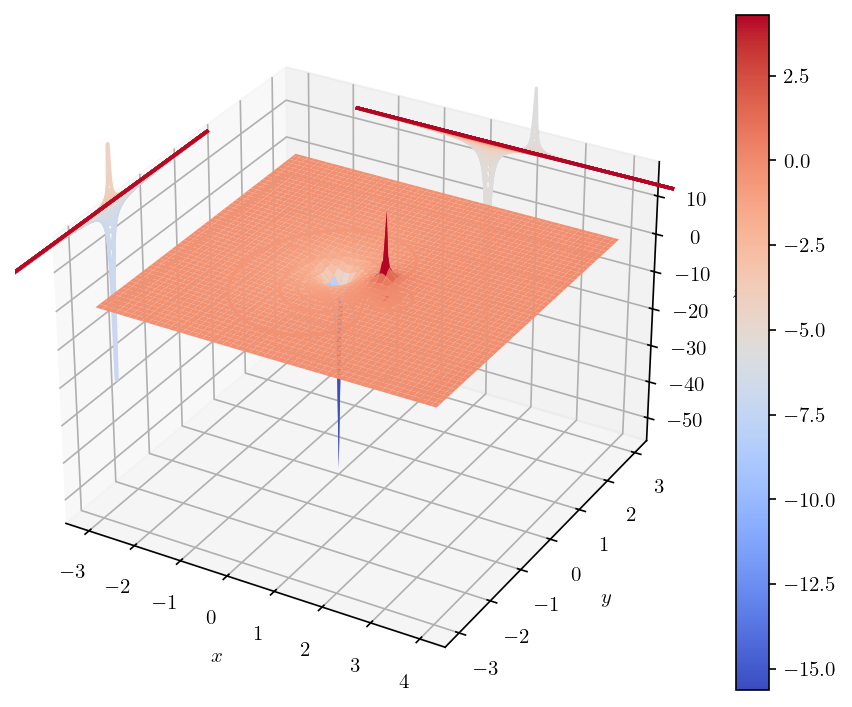

In [87]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, dpi=150)

surface = ax.plot_surface(X_f, Y_f, V ,antialiased=True,cmap='coolwarm')
plt.contour(X_f, Y_f, V,200,zdir='x', offset=-5,cmap='coolwarm')
plt.contour(X_f, Y_f, V,200,zdir='y', offset=5,cmap='coolwarm')
plt.contour(X_f, Y_f, V,200,zdir='z', offset=-5,cmap='coolwarm')
plt.colorbar(surface)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$z$')
plt.tight_layout()

2.10

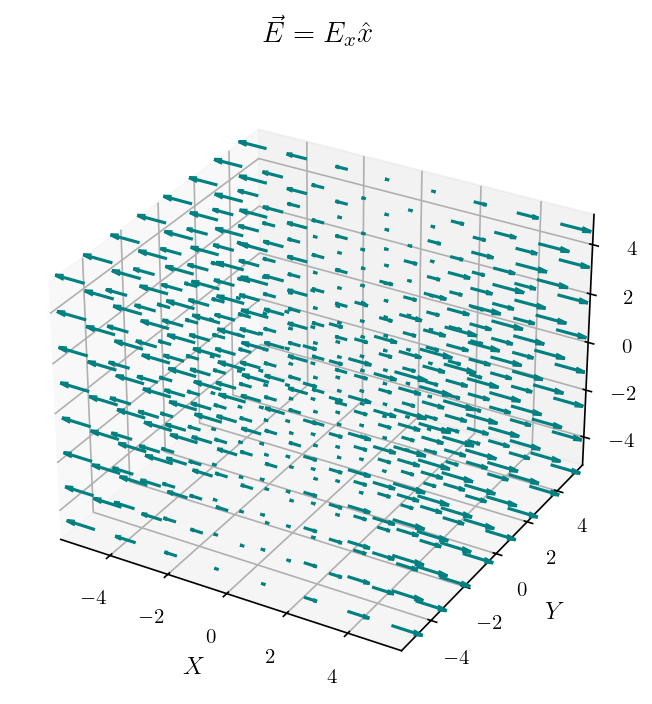

In [115]:
x = np.linspace(-5, 5, 8)
y = np.linspace(-5, 5, 8)
z = np.linspace(-5, 5, 8)

X, Y, Z = np.meshgrid(x, y, z)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, dpi=150)
EX = X
EY = np.zeros_like(X)
EZ = np.zeros_like(X)
ax.quiver(X, Y, Z, EX, EY, EZ, length=0.2, color='teal', normalize=False, arrow_length_ratio=0.3)
ax.set_title(r'$\vec{E}=E_x \hat{x}$', fontsize=14, pad=20)
ax.set_xlabel('$X$', fontsize=12)
ax.set_ylabel('$Y$', fontsize=12)
ax.set_zlabel('$Z$', fontsize=12)
plt.tight_layout()